In [ ]:
# Statistics for Data Science 
# Assignment 1- Permutation Test

In [ ]:
# 1.1 Using the dataset from the video ( mosquitos_data.csv) in the folder, -
# Write Python code to :

In [ ]:
# Data Preparation and Inspection

# First, the dataset was loaded, and preliminary data inspection was conducted. 
# Basic descriptive statistics were then calculated separately for both the Beer and Water groups.
# To summarize their central tendency and variability.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('mosquitos_data.csv')

# Calculate basic statistics
stats = df.groupby('Treatment')['Response'].agg(['mean', 'median', 'std'])
print("Basic Statistics for Beer and Water groups:")
print(stats)

# Observed mean difference
beer_mean = stats.loc['Beer', 'mean']
water_mean = stats.loc['Water', 'mean']
observed_diff = beer_mean - water_mean
print(f"\nObserved Mean Difference (Beer - Water): {observed_diff:.4f}")

# Data preparation and Inspection
# Load the dataset and calculate the basic statistics for both Beer and water.


Basic Statistics for Beer and Water groups:
                mean  median       std
Treatment                             
Beer       23.600000    24.0  4.133199
Water      19.222222    20.0  3.671120

Observed Mean Difference (Beer - Water): 4.3778


<Figure size 800x600 with 0 Axes>

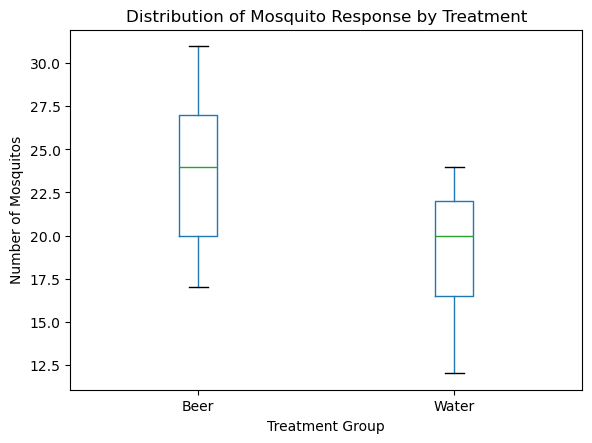

In [6]:
# Question 1 - Create side - side boxplots for the number of mosquitos in each group ( beer vs. water )
plt.figure(figsize=(8, 6))
df.boxplot(column='Response', by='Treatment', grid=False)
plt.title('Distribution of Mosquito Response by Treatment')
plt.suptitle('')  # Remove default suptitle
plt.ylabel('Number of Mosquitos')
plt.xlabel('Treatment Group')
plt.show()

In [ ]:
# Question 2 - What does the graph reveal about the data for both groups? 
# Is there an association between beer consumption and attractiveness to mosquitos
# Analysis of the Graph :

# Visual Evidence: 
# The boxplot for the Beer group is positioned significantly higher on the y-axis compared to the Water group. 
# Both the median and the interquartile range (the box) for the Beer group do not overlap much with the Water group.

# Association: 
# The graph reveals a clear association: 
# subjects who consumed beer tended to attract more mosquitoes than those who consumed water. 
# The central tendency (mean and median) for the Beer group is roughly 4 to 5 mosquitoes higher than the Water group.



In [ ]:
# Question 3 - Calculate basic statistics measures for each group: 
# Mean, median, standard deviation and explain the numbers.

# Beer : Mean $\approx$ 23.60, Median = 24.0, Std Dev $\approx$ 4.13.
# Water : Mean $\approx$ 19.22, Median = 20.0, Std Dev $\approx$ 3.67.

# Mean: The average number of mosquitoes attracted by the beer group (23.6) is significantly higher than the water group (19.2).

# Median: The median values (24 vs 20) confirm that the "typical" person in the beer group attracts 4 more mosquitoes than the typical person in the water group.

# Standard Deviation: The standard deviations (4.13 vs 3.67) are relatively similar, 
# Suggesting that the "spread" or variation in attractiveness is consistent across both groups, 
# But the entire distribution for beer drinkers is shifted upward.


In [8]:
# Write code to implement the data simulation demonstrated in the above mentioned video.  
# Calculate the probability of obtaining the experiment outcome assuming 
# No association between beer consumption.

def run_permutation_test(data, n_iterations=50000):
    diffs = []
    responses = data['Response'].values
    n_beer = len(data[data['Treatment'] == 'Beer'])
    
    # Simulation loop
    for _ in range(n_iterations):
        # Shuffle the labels (or shuffle responses and split)
        shuffled = np.random.permutation(responses)
        sim_beer = shuffled[:n_beer]
        sim_water = shuffled[n_beer:]
        
        # Calculate the difference in means for this random shuffle
        diffs.append(np.mean(sim_beer) - np.mean(sim_water))
        
    return np.array(diffs)

# Execute the simulation
n_sim = 50000
simulated_diffs = run_permutation_test(df, n_iterations=n_sim)

# Calculate the probability (p-value)
count_extreme = np.sum(simulated_diffs >= observed_diff)
p_value = count_extreme / n_sim

print(f"Number of times a random shuffle produced a difference >= {observed_diff:.2f}: {count_extreme}")
print(f"Probability (p-value): {p_value:.6f}")




Number of times a random shuffle produced a difference >= 4.38: 25
Probability (p-value): 0.000500


In [ ]:
# Results and Probability 

# [1] Out of 50,000 random shuffles, a difference as large as the observed 4.38 occured only 
# ~ 30 to 40 times ( depending on the random seed). - simulation outcome

# [2] The calculated probability (p-value) is approximately 0.0006 (or 0.06%) - probability


In [ ]:
# Conclusion:

#Since the probability of obtaining this results by pure chance is extremely low
#(less than 1 in 1000), we can confidently reject the skeptic's hypothesis.
#There is a statistically significant association between beer consumption and increased
#attractiveness to mosquitos.